In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import mesa
import matplotlib.pylab as plt
import seaborn as sns

from model import PublishingModel

In [3]:
params = {
    "n_groups": 1000,
    "n_journals": 100,
    "enable_economics": False,
    "prestige_decay": 0, # 0.001,
    "beta_p": 0.5,
    "prestige_social_multiplier": 0,
    "gamma": 500
}
max_steps = 200

result = mesa.batch_run(
    PublishingModel,
    number_processes=None,
    iterations=40,
    data_collection_period=1,
    parameters=params,
    max_steps=max_steps
)

df = pd.DataFrame(result)

  0%|          | 0/40 [00:00<?, ?it/s]

In [4]:
df.head()

,RunId,iteration,Step,n_groups,n_journals,enable_economics,prestige_decay,beta_p,prestige_social_multiplier,gamma,...,AvgQuality,AgentID,Prestige,Budget,Reputation,Revenue,Type,Category,NPapers,ResearchQuality
0,0,0,0,1000,100,False,0,0.5,0,500,...,2.838977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,1,1000,100,False,0,0.5,0,500,...,2.853065,1.0,NaN,NaN,1.000000,0.0,JournalAgent,predatory,0.0,NaN
2,0,0,1,1000,100,False,0,0.5,0,500,...,2.853065,2.0,NaN,NaN,1.399890,0.0,JournalAgent,predatory,3.0,NaN
3,0,0,1,1000,100,False,0,0.5,0,500,...,2.853065,3.0,NaN,NaN,1.000000,0.0,JournalAgent,predatory,0.0,NaN
4,0,0,1,1000,100,False,0,0.5,0,500,...,2.853065,4.0,NaN,NaN,1.124205,0.0,JournalAgent,predatory,1.0,NaN


### Prestige & reputation

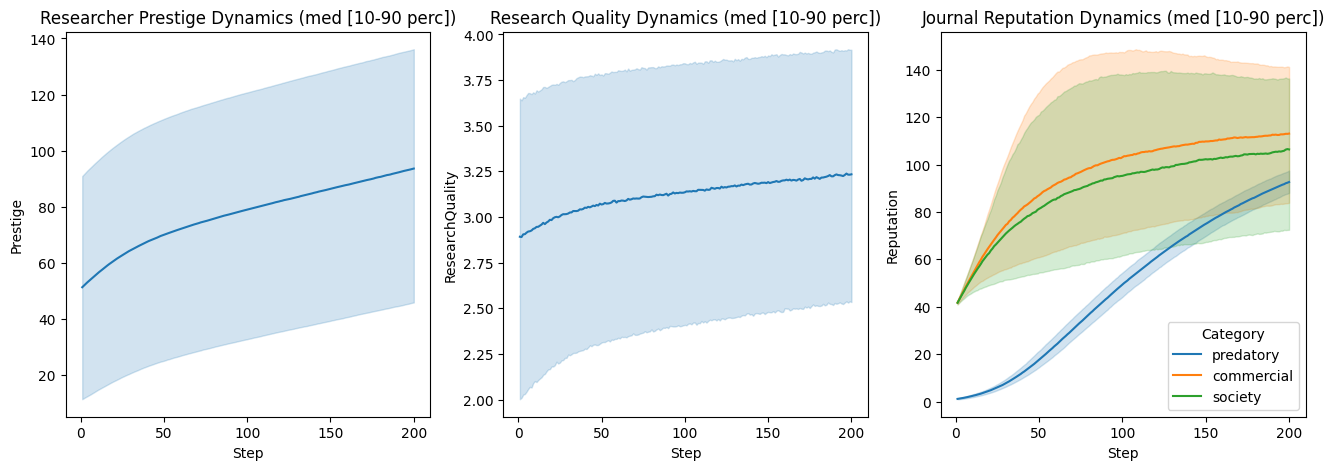

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Researchers
researcher_df = df[df["Type"] == "ResearcherGroupAgent"]
sns.lineplot(
    data=researcher_df,
    x='Step', y='Prestige',
    estimator=np.median,
    errorbar=('pi', 80),
    ax=axes[0]
)
axes[0].set_title("Researcher Prestige Dynamics (med [10-90 perc])")

sns.lineplot(
    data=researcher_df,
    x='Step', y='ResearchQuality',
    estimator=np.median,
    errorbar=('pi', 80),
    ax=axes[1]
)
axes[1].set_title("Research Quality Dynamics (med [10-90 perc])")

# Journals
sns.lineplot(
    data=df[df["Type"] == "JournalAgent"],
    x='Step', y='Reputation', hue='Category',
    estimator=np.median,
    errorbar=('pi', 80),
    ax=axes[2]
)
axes[2].set_title("Journal Reputation Dynamics (med [10-90 perc])")

plt.show()




### Dynamics of Papers

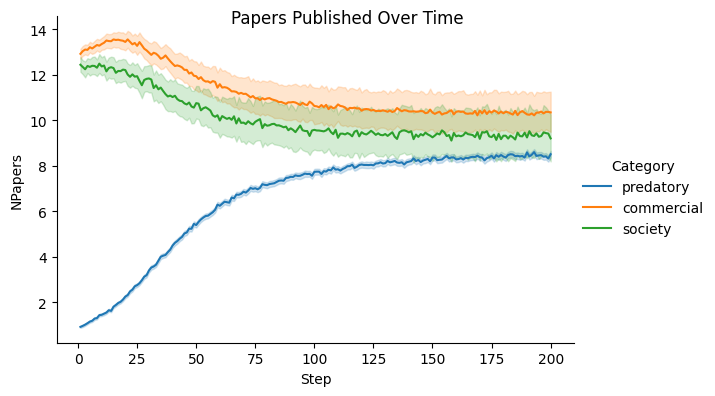

In [6]:
# Filter for JournalAgents to avoid errors
journal_df = df[df["Type"] == "JournalAgent"]


g1 = sns.relplot(
    data=journal_df,
    x='Step', y='NPapers', hue='Category',
    kind='line', estimator=np.mean, errorbar='ci',
    height=4, aspect=1.5
)
g1.fig.suptitle("Papers Published Over Time")
plt.show()

### Distributions Start vs End

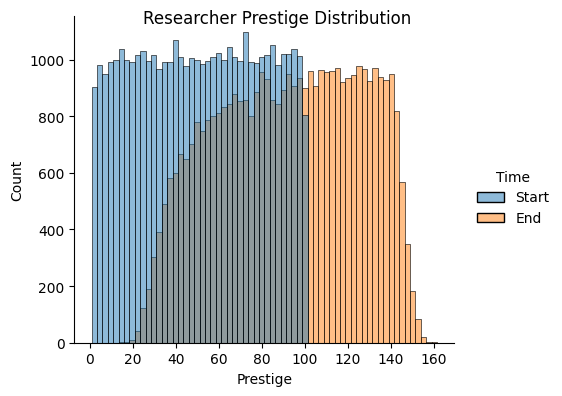

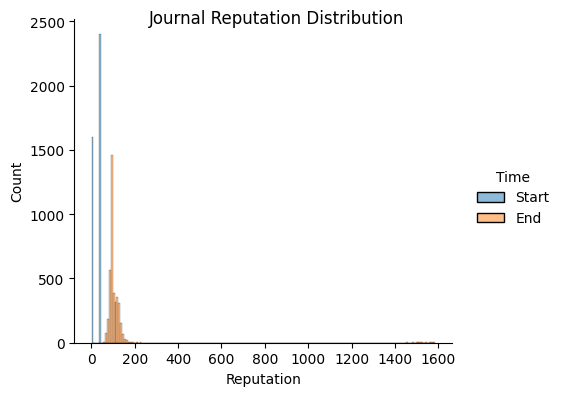

In [7]:
steps_to_compare = [1, max_steps]
df_dist = df[df['Step'].isin(steps_to_compare)].copy()
df_dist['Time'] = df_dist['Step'].replace({1: 'Start', max_steps: 'End'})

g3 = sns.displot(
    data=df_dist[df_dist["Type"] == "ResearcherGroupAgent"],
    x="Prestige", hue="Time",
    kind="hist", fill=True, common_norm=False, height=4, aspect=1.2,
)
g3.fig.suptitle("Researcher Prestige Distribution")
plt.show()

g4 = sns.displot(
    data=df_dist[df_dist["Type"] == "JournalAgent"],
    x="Reputation", hue="Time",
    kind="hist", fill=True, common_norm=False, height=4, aspect=1.2
)
g4.fig.suptitle("Journal Reputation Distribution")
plt.show()

### Gini Coefficients

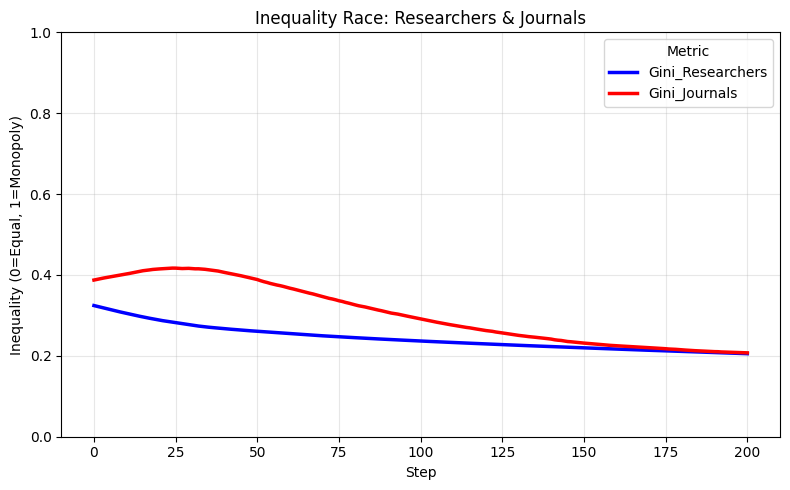

In [8]:
# Group by Step and take median of the model-level reporters (Gini)
# Note: Gini is recorded at every row for that step, but it's the same for all agents in that step/run
# We aggregate by Step across iterations
df_gini = df.groupby("Step")[["Gini_Researchers", "Gini_Journals"]].median().reset_index()

df_melted = df_gini.melt(
    id_vars=["Step"],
    value_vars=["Gini_Researchers", "Gini_Journals"],
    var_name="Metric",
    value_name="Gini Coefficient"
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_melted,
    x="Step",
    y="Gini Coefficient",
    hue="Metric",
    palette={"Gini_Researchers": "blue", "Gini_Journals": "red"},
    linewidth=2.5,
)

plt.title("Inequality Race: Researchers & Journals")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.ylabel("Inequality (0=Equal, 1=Monopoly)")
plt.tight_layout()
plt.show()